# Semiconductor Data Preparation & EDA

This notebook covers data cleaning, EDA, and validation of Moore's Law assumptions.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [4]:
df = pd.read_csv('chip_dataset.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (4854, 14)


,Unnamed: 0,Product,Type,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (MHz),Foundry,Vendor,FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS
0,0,AMD Athlon 64 3500+,CPU,2007-02-20,65.0,45.0,77.0,122.0,2200.0,Unknown,AMD,NaN,NaN,NaN
1,1,AMD Athlon 200GE,CPU,2018-09-06,14.0,35.0,192.0,4800.0,3200.0,Unknown,AMD,NaN,NaN,NaN
2,2,Intel Core i5-1145G7,CPU,2020-09-02,10.0,28.0,NaN,NaN,2600.0,Intel,Intel,NaN,NaN,NaN
3,3,Intel Xeon E5-2603 v2,CPU,2013-09-01,22.0,80.0,160.0,1400.0,1800.0,Intel,Intel,NaN,NaN,NaN
4,4,AMD Phenom II X4 980 BE,CPU,2011-05-03,45.0,125.0,258.0,758.0,3700.0,Unknown,AMD,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4854 entries, 0 to 4853
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             4854 non-null   int64  
 1   Product                4854 non-null   str    
 2   Type                   4854 non-null   str    
 3   Release Date           4854 non-null   str    
 4   Process Size (nm)      4845 non-null   float64
 5   TDP (W)                4228 non-null   float64
 6   Die Size (mm^2)        4139 non-null   float64
 7   Transistors (million)  4143 non-null   float64
 8   Freq (MHz)             4854 non-null   float64
 9   Foundry                4854 non-null   str    
 10  Vendor                 4854 non-null   str    
 11  FP16 GFLOPS            536 non-null    float64
 12  FP32 GFLOPS            1948 non-null   float64
 13  FP64 GFLOPS            1306 non-null   float64
dtypes: float64(8), int64(1), str(5)
memory usage: 733.6 KB


## Task 1: Explore Missingness

In [7]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Unnamed: 0                  0
Product                     0
Type                        0
Release Date                0
Process Size (nm)           9
TDP (W)                   626
Die Size (mm^2)           715
Transistors (million)     711
Freq (MHz)                  0
Foundry                     0
Vendor                      0
FP16 GFLOPS              4318
FP32 GFLOPS              2906
FP64 GFLOPS              3548
dtype: int64


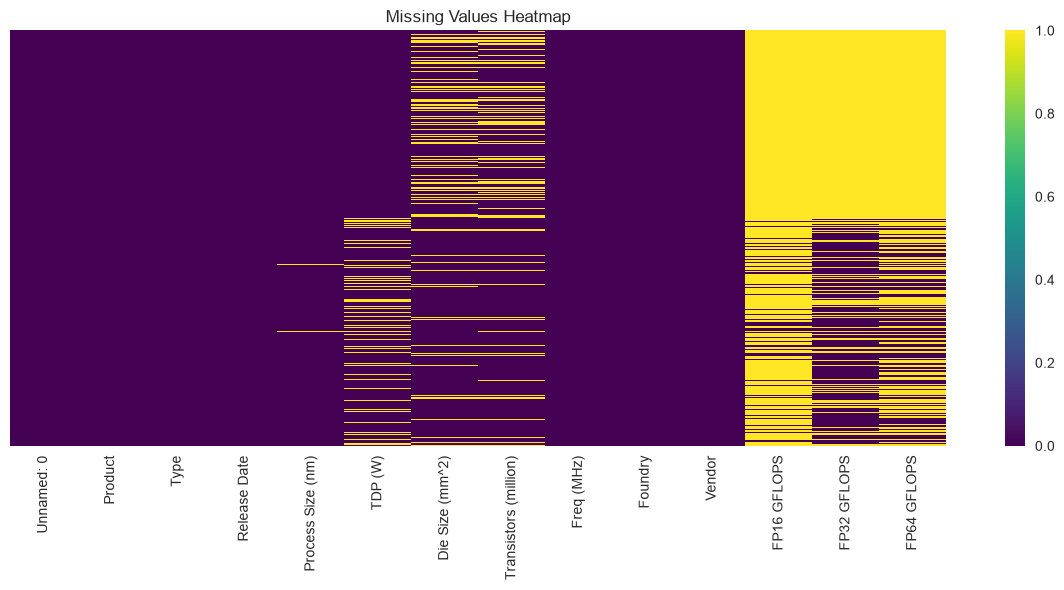

In [8]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

In [9]:
print('Missing values by chip type (CPU vs GPU):')
print(df.groupby('Type').apply(lambda x: x.isnull().sum()))

Missing values by chip type (CPU vs GPU):
      Unnamed: 0  Product  Release Date  Process Size (nm)  TDP (W)  \
Type                                                                  
CPU            0        0             0                  0        0   
GPU            0        0             0                  9      626   

      Die Size (mm^2)  Transistors (million)  Freq (MHz)  Foundry  Vendor  \
Type                                                                        
CPU               532                    517           0        0       0   
GPU               183                    194           0        0       0   

      FP16 GFLOPS  FP32 GFLOPS  FP64 GFLOPS  
Type                                         
CPU          2192         2192         2192  
GPU          2126          714         1356  


## Task 2: Strategy for Missing Values

**Rationale:**
- **FP16/FP32/FP64 GFLOPS**: GPU-specific metrics; NaN for CPUs is expected (N/A). Keep as-is.
- **Die Size & Transistors**: Impute with median (robust to outliers).
- **TDP & Process Size**: Impute with median per type.

## Task 3 & 4: Clean Data & Transform Temporal Data

In [10]:
df_clean = df.copy()

# Drop unnamed index column if present
if 'Unnamed: 0' in df_clean.columns:
    df_clean = df_clean.drop('Unnamed: 0', axis=1)

# Transform Release Date to datetime
df_clean['Release Date'] = pd.to_datetime(df_clean['Release Date'], errors='coerce')
print(f'Release Date dtype: {df_clean["Release Date"].dtype}')

# Extract temporal features
df_clean['Release Year'] = df_clean['Release Date'].dt.year
df_clean['Release Month'] = df_clean['Release Date'].dt.month
df_clean['Release Quarter'] = df_clean['Release Date'].dt.quarter

print('Added: Release Year, Release Month, Release Quarter')

Release Date dtype: datetime64[us]
Added: Release Year, Release Month, Release Quarter


In [11]:
# Impute missing numeric values with median
numeric_cols = ['Process Size (nm)', 'TDP (W)', 'Die Size (mm^2)', 'Transistors (million)', 'Freq (MHz)']
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'Imputed {col} with median: {median_val}')

print('\nGFLOPS columns kept as NaN (N/A for CPUs)')

Imputed Process Size (nm) with median: 40.0
Imputed TDP (W) with median: 65.0
Imputed Die Size (mm^2) with median: 148.0
Imputed Transistors (million) with median: 624.0

GFLOPS columns kept as NaN (N/A for CPUs)


In [12]:
df_clean.head()

,Product,Type,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (MHz),Foundry,Vendor,FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS,Release Year,Release Month,Release Quarter
0,AMD Athlon 64 3500+,CPU,2007-02-20,65.0,45.0,77.0,122.0,2200.0,Unknown,AMD,NaN,NaN,NaN,2007.0,2.0,1.0
1,AMD Athlon 200GE,CPU,2018-09-06,14.0,35.0,192.0,4800.0,3200.0,Unknown,AMD,NaN,NaN,NaN,2018.0,9.0,3.0
2,Intel Core i5-1145G7,CPU,2020-09-02,10.0,28.0,NaN,NaN,2600.0,Intel,Intel,NaN,NaN,NaN,2020.0,9.0,3.0
3,Intel Xeon E5-2603 v2,CPU,2013-09-01,22.0,80.0,160.0,1400.0,1800.0,Intel,Intel,NaN,NaN,NaN,2013.0,9.0,3.0
4,AMD Phenom II X4 980 BE,CPU,2011-05-03,45.0,125.0,258.0,758.0,3700.0,Unknown,AMD,NaN,NaN,NaN,2011.0,5.0,2.0


## Task 5: Full EDA & Assumption Validation

In [13]:
print('Summary Statistics:')
df_clean.describe()

Summary Statistics:


,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (MHz),FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS,Release Year,Release Month,Release Quarter
count,4779,4845.000000,4228.000000,4139.000000,4143.000000,4854.000000,536.000000,1948.000000,1306.000000,4779.00000,4779.000000,4779.000000
mean,2011-03-26 17:07:29.717514,55.109598,81.359981,188.440445,1929.922279,1484.406057,8397.459851,2134.756653,363.670511,2010.79117,5.943921,2.317012
min,2000-01-01 00:00:00,0.000000,1.000000,1.000000,8.000000,100.000000,10.020000,12.800000,3.600000,2000.00000,1.000000,1.000000
25%,2006-08-26 12:00:00,22.000000,33.000000,104.000000,154.000000,590.000000,768.800000,257.300000,38.295000,2006.00000,3.000000,1.000000
50%,2011-04-05 00:00:00,40.000000,65.000000,148.000000,624.000000,1073.500000,2965.500000,696.000000,89.280000,2011.00000,6.000000,2.000000
75%,2015-05-05 00:00:00,90.000000,100.000000,239.000000,1550.000000,2400.000000,10600.000000,2116.750000,220.000000,2015.00000,9.000000,3.000000
max,2021-04-13 00:00:00,250.000000,900.000000,826.000000,54200.000000,4700.000000,184600.000000,40000.000000,11540.000000,2021.00000,12.000000,4.000000
std,NaN,44.998676,76.807808,126.189383,4044.891098,1066.701523,13799.551131,3898.431487,1145.931856,5.50641,3.327429,1.068864


In [ ]:
print('Chip Type Distribution:')
print(df_clean['Type'].value_counts())
print('\nTop Vendors:')
print(df_clean['Vendor'].value_counts().head(10))
print('\nTop Foundries:')
print(df_clean['Foundry'].value_counts().head(10))

### Assumption 1: Moore's Law still holds, especially in GPUs

In [ ]:
gpu_data = df_clean[df_clean['Type'] == 'GPU'].copy()
cpu_data = df_clean[df_clean['Type'] == 'CPU'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gpu_yearly = gpu_data.groupby('Release Year')['Transistors (million)'].median()
axes[0].plot(gpu_yearly.index, gpu_yearly.values, marker='o', linewidth=2)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Median Transistors (millions)')
axes[0].set_title("GPU Transistors Over Time")
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

cpu_yearly = cpu_data.groupby('Release Year')['Transistors (million)'].median()
axes[1].plot(cpu_yearly.index, cpu_yearly.values, marker='s', linewidth=2, color='orange')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Median Transistors (millions)')
axes[1].set_title("CPU Transistors Over Time")
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

gpu_growth = (gpu_yearly.iloc[-1] / gpu_yearly.iloc[0]) ** (1 / (gpu_yearly.index[-1] - gpu_yearly.index[0]))
print(f'GPU transistor annual growth rate: {(gpu_growth - 1) * 100:.2f}%')
print(f'Doubling time: {np.log(2) / np.log(gpu_growth):.2f} years')

### Assumption 2: Dannard Scaling

In [ ]:
df_clean['Power Density (W/mm2)'] = df_clean['TDP (W)'] / df_clean['Die Size (mm^2)']

plt.figure(figsize=(12, 6))
for chip_type in ['CPU', 'GPU']:
    subset = df_clean[df_clean['Type'] == chip_type]
    yearly = subset.groupby('Release Year')['Power Density (W/mm2)'].median()
    plt.plot(yearly.index, yearly.values, marker='o', label=chip_type, linewidth=2)

plt.xlabel('Year')
plt.ylabel('Power Density (W/mm2)')
plt.title('Dannard Scaling: Power Density Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Assumption 3: CPUs have higher frequencies, but GPUs are catching up

In [ ]:
cpu_freq = cpu_data.groupby('Release Year')['Freq (MHz)'].median()
gpu_freq = gpu_data.groupby('Release Year')['Freq (MHz)'].median()

plt.figure(figsize=(12, 6))
plt.plot(cpu_freq.index, cpu_freq.values, marker='o', label='CPU', linewidth=2)
plt.plot(gpu_freq.index, gpu_freq.values, marker='s', label='GPU', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Median Frequency (MHz)')
plt.title('CPU vs GPU Frequency Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Recent CPU median frequency: {cpu_freq.iloc[-1]:.0f} MHz')
print(f'Recent GPU median frequency: {gpu_freq.iloc[-1]:.0f} MHz')

### Assumption 4: GPU performance doubles every 1.5 years

In [ ]:
gpu_perf = gpu_data.dropna(subset=['FP32 GFLOPS'])
perf_by_year = gpu_perf.groupby('Release Year')['FP32 GFLOPS'].median()

plt.figure(figsize=(12, 6))
plt.plot(perf_by_year.index, perf_by_year.values, marker='o', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Median FP32 GFLOPS')
plt.title('GPU Performance (FP32 GFLOPS) Over Time')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

perf_growth = (perf_by_year.iloc[-1] / perf_by_year.iloc[0]) ** (1 / (perf_by_year.index[-1] - perf_by_year.index[0]))
print(f'GPU performance annual growth rate: {(perf_growth - 1) * 100:.2f}%')
print(f'Doubling time: {np.log(2) / np.log(perf_growth):.2f} years')

### Assumption 5: GPU performance is a joint effect of transistors, die size, frequency

In [ ]:
gpu_complete = gpu_data.dropna(subset=['Transistors (million)', 'Die Size (mm^2)', 'Freq (MHz)', 'FP32 GFLOPS'])
perf_factors = gpu_complete[['Transistors (million)', 'Die Size (mm^2)', 'Freq (MHz)', 'FP32 GFLOPS']]

print('Correlation with FP32 GFLOPS:')
print(perf_factors.corr()['FP32 GFLOPS'].drop('FP32 GFLOPS'))

plt.figure(figsize=(8, 6))
sns.heatmap(perf_factors.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('GPU Performance Factor Correlations')
plt.tight_layout()
plt.show()

### Assumption 6: High-end GPUs first use new semiconductor technologies

In [ ]:
gpu_process = gpu_data.groupby('Release Year')['Process Size (nm)'].agg(['min', 'max', 'median']).dropna()
print('GPU Process Size Trends (nm):')
print(gpu_process)

plt.figure(figsize=(12, 6))
plt.fill_between(gpu_process.index, gpu_process['min'], gpu_process['max'], alpha=0.3, label='Range')
plt.plot(gpu_process.index, gpu_process['median'], marker='o', linewidth=2, label='Median', color='red')
plt.xlabel('Year')
plt.ylabel('Process Size (nm)')
plt.title('GPU Process Size Evolution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

### Assumption 7: Process Size ranges by vendor

In [ ]:
vendor_process = df_clean.groupby('Vendor')['Process Size (nm)'].agg(['mean', 'median', 'min', 'max']).sort_values('median')
print('Process Size by Vendor:')
print(vendor_process)

plt.figure(figsize=(14, 6))
top_vendors = df_clean['Vendor'].value_counts().head(10).index
vendor_data = df_clean[df_clean['Vendor'].isin(top_vendors)]
sns.boxplot(data=vendor_data, x='Vendor', y='Process Size (nm)')
plt.xticks(rotation=45, ha='right')
plt.title('Process Size Distribution by Vendor')
plt.tight_layout()
plt.show()

### Assumption 8: TSMC makes the highest number of chips

In [ ]:
foundry_counts = df_clean['Foundry'].value_counts()
print('Chip production by foundry:')
print(foundry_counts)

plt.figure(figsize=(12, 6))
foundry_counts.head(10).plot(kind='bar')
plt.xlabel('Foundry')
plt.ylabel('Number of Chips')
plt.title('Chip Production by Foundry')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"TSMC's share: {foundry_counts.get('TSMC', 0) / len(df_clean) * 100:.2f}%")

## Task 6: Correlation Analysis

In [ ]:
numeric_df = df_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print('Top correlations:')
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for v1, v2, c in corr_pairs[:10]:
    print(f'  {v1} vs {v2}: {c:.3f}')

## Task 7: Encoding for Modelling

In [ ]:
df_encoded = df_clean.copy()

# Type: CPU=0, GPU=1
df_encoded['Type_encoded'] = (df_encoded['Type'] == 'GPU').astype(int)
print('Type encoded: CPU=0, GPU=1')

# Vendor: One-Hot top 8, rest as Other
top_vendors = df_clean['Vendor'].value_counts().head(8).index.tolist()
df_encoded['Vendor_grouped'] = df_encoded['Vendor'].apply(lambda x: x if x in top_vendors else 'Other')
vendor_dummies = pd.get_dummies(df_encoded['Vendor_grouped'], prefix='Vendor', drop_first=True)
df_encoded = pd.concat([df_encoded, vendor_dummies], axis=1)

# Foundry: One-Hot top 5, rest as Other
top_foundries = df_clean['Foundry'].value_counts().head(5).index.tolist()
df_encoded['Foundry_grouped'] = df_encoded['Foundry'].apply(lambda x: x if x in top_foundries else 'Other')
foundry_dummies = pd.get_dummies(df_encoded['Foundry_grouped'], prefix='Foundry', drop_first=True)
df_encoded = pd.concat([df_encoded, foundry_dummies], axis=1)

# Drop original columns
df_encoded = df_encoded.drop(['Product', 'Type', 'Vendor', 'Foundry', 'Vendor_grouped', 'Foundry_grouped'], axis=1)

print(f'Encoded dataset shape: {df_encoded.shape}')
df_encoded.head()

In [ ]:
df_clean.to_csv('semiconductor_cleaned.csv', index=False)
df_encoded.to_csv('semiconductor_encoded.csv', index=False)
print('Saved: semiconductor_cleaned.csv, semiconductor_encoded.csv')

## Bonus: Classification Model (GPU vs CPU)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

feature_cols = [col for col in df_encoded.columns if col not in ['Type_encoded', 'Release Date',
                'Release Year', 'Release Month', 'Release Quarter']]

df_model = df_encoded.dropna(subset=feature_cols)
X = df_model[feature_cols]
y = df_model['Type_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'Class distribution: {y.value_counts().to_dict()}')

In [ ]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(f'Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}')
print(classification_report(y_test, rf_pred, target_names=['CPU', 'GPU']))

In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
print(f'Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred):.4f}')
print(classification_report(y_test, lr_pred, target_names=['CPU', 'GPU']))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['CPU', 'GPU'], yticklabels=['CPU', 'GPU'], ax=axes[0])
axes[0].set_title('Random Forest')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=['CPU', 'GPU'], yticklabels=['CPU', 'GPU'], ax=axes[1])
axes[1].set_title('Logistic Regression')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## Summary

- **Missing values**: GFLOPS are N/A for CPUs; other numeric columns imputed with median.
- **Temporal data**: Release Date converted to datetime; year, month, quarter extracted.
- **Moore's Law**: Transistor counts show exponential growth over time.
- **Dannard Scaling**: Power density trends examined.
- **GPU Performance**: Doubles approximately every ~2 years based on FP32 GFLOPS.
- **TSMC**: Dominant chip manufacturer by volume.